# SPECT Image Reconstruction with SIRF/STIR

In this notebook, the **Lu-177 projection data** generated with SIMIND are reconstructed using **SIRF/STIR**.

The workflow demonstrates how to:

- load conventionally **TEW scatter-corrected** projection data;
- define the reconstruction image geometry;
- construct a SPECT acquisition model incorporating **attenuation** and **collimator-detector response**;
- define a **Poisson log-likelihood** objective function;
- perform iterative **OSEM reconstruction**; and
- compare reconstructions **with and without resolution modelling**.

The quantitative performance of the reconstruction is evaluated in the next notebook using the known digital source distribution.


In [1]:
%matplotlib inline

import sys
from pathlib import Path

import numpy as np
import sirf.STIR as spect

sys.path.insert(0, "/home/jovyan/sirf-demo/.packages")
import stir_simind_utils as utils

spect.set_verbosity(0)

demo_path = Path("/home/jovyan/sirf-demo/SIRF-demo-1")


## Select the Lu-177 Dataset

The Lu-177 acquisition generated in the previous notebook is used here.

The projection data have already undergone **conventional triple-energy-window (TEW) scatter correction**, i.e. the TEW scatter estimate has been subtracted from the photopeak projections before reconstruction.

This notebook therefore does **not** use scatter as an additive term in the forward model.


In [2]:
sim_dir = demo_path / "simind_data" / "lu177_128"

# Conventionally TEW scatter-corrected projection data
projection_path = sim_dir / "tomo" / "lu177_simulation_tew.hs"

# Attenuation map
attenuation_path = sim_dir / "input" / "nema_lu_ctac.hv"


## Load the Projection Data and Define Reconstruction Parameters

The TEW-corrected projection data and corresponding attenuation map are loaded into SIRF/STIR.

The reconstruction image geometry is defined as a **128 × 128 × 128** matrix with **4.42 mm isotropic voxels**.

The reconstruction uses:

- **2 subsets**
- **100 subiterations**
- intermediate images saved every **10 subiterations**

A **subiteration** is one subset update. With 2 subsets, 100 subiterations correspond to 50 complete passes through all subsets.


In [3]:
acquisition_data = spect.AcquisitionData(str(projection_path))
attenuation_map = spect.ImageData(str(attenuation_path))

# Reconstruction image geometry
matrix_size = (128,) * 3
voxel_size = (4.42,) * 3

# OSEM parameters
subiterations = 100
subsets = 2
save_interval = 10

# Output for the reconstruction with resolution modelling
recon_dir = sim_dir / "recons" / "osem_rm"
recon_dir.mkdir(parents=True, exist_ok=True)

name_prefix = "lu177_sim_osem_rm"

keep_views_in_cache = True


## Create the Initial Image

Iterative reconstruction requires an **initial estimate** of the activity distribution.

A SIRF/STIR `ImageData` object is created with the required reconstruction geometry and initialised uniformly to **1**. This provides the starting estimate that is subsequently updated by OSEM.


In [4]:
initial_image = spect.ImageData(acquisition_data)
initial_image.initialise(matrix_size, vsize=voxel_size)
initial_image.set_modality("NM")
initial_image.fill(1)


## Configure the SPECT System Model

The acquisition model describes how an activity distribution in image space produces SPECT projection data.

A `SPECTUBMatrix` is used to model:

- **attenuation**, using the phantom attenuation map; and
- **collimator-detector response**, using a distance-dependent resolution model.

For the prepared workshop dataset, the attenuation image is flipped along array axis 2 to reconcile the orientation of the generated phantom data with the orientation expected by this STIR setup. This is a dataset-specific orientation step rather than a general requirement for SPECT reconstruction.

The distance-dependent collimator-detector response was characterised specifically for this simulated imaging system using **SIMIND line-source simulations at different source-to-detector distances**. The measured spatial resolution was fitted as a function of distance, and the resulting **intercept (`sigma_0`) and slope** are used to parameterise the STIR resolution model.

These parameters therefore describe the distance-dependent resolution of the simulated camera/collimator configuration used in this workshop and should be re-characterised if the imaging-system configuration is changed.


In [5]:
# Resolution-model parameters derived from SIMIND line-source simulations
# performed at multiple source-to-detector distances
sigma_0 = 2.35598  # mm
slope = 0.01771

acq_model_matrix = spect.SPECTUBMatrix()
acq_model_matrix.set_keep_all_views_in_cache(keep_views_in_cache)

# Attenuation correction
flipped_attenuation_map = attenuation_map.clone()
flipped_attenuation_map.fill(
    np.flip(attenuation_map.as_array(), axis=2)
)
acq_model_matrix.set_attenuation_image(flipped_attenuation_map)

# Collimator-detector response / resolution modelling
acq_model_matrix.set_resolution_model(
    float(sigma_0),
    float(slope),
    full_3D=False,
)

# Build and initialise the acquisition model
acquisition_model = spect.AcquisitionModelUsingMatrix(acq_model_matrix)
acquisition_model.set_up(acquisition_data, initial_image)


## Define the Objective Function

Emission-tomography reconstruction can be formulated as an optimisation problem based on a statistical model of the measured projection data.

Here, SIRF/STIR constructs a **Poisson log-likelihood objective function** from the TEW-corrected acquisition data and associates it with the SPECT acquisition model defined above.

The objective function therefore combines the projection data with the physical system model used during iterative reconstruction.


In [6]:
objective_function = spect.make_Poisson_loglikelihood(acquisition_data)
objective_function.set_acquisition_model(acquisition_model)


## Perform the OSEM Reconstruction

The image is reconstructed using **Ordered Subsets Expectation Maximisation (OSEM)**.

SIRF/STIR provides OSEM through the more general `OSMAPOSLReconstructor`. With no prior or penalty specified here, it performs the ordered-subsets maximum-likelihood reconstruction used in this demonstration.

The reconstruction pipeline is therefore:

**TEW scatter correction → attenuation modelling → resolution modelling → iterative OSEM reconstruction**

Intermediate images are saved every 10 subiterations for subsequent evaluation.


In [7]:
reconstructed_image = initial_image.clone()

reconstructor = spect.OSMAPOSLReconstructor()
reconstructor.set_num_subiterations(subiterations)
reconstructor.set_num_subsets(subsets)

# Save intermediate reconstruction results
reconstructor.set_save_interval(save_interval)
reconstructor.enable_output()
reconstructor.set_output_filename_prefix(str(recon_dir / name_prefix))

reconstructor.set_objective_function(objective_function)

reconstructor.set_up(reconstructed_image)
reconstructor.reconstruct(reconstructed_image)


## Compare Reconstructions With and Without Resolution Modelling

To illustrate the effect of collimator-detector response modelling, selected reconstruction stages are compared with previously generated OSEM reconstructions without resolution modelling.

The same intensity scale is used for OSEM and OSEM-RM. The third panel shows:

(OSEM-RM) - (OSEM)

so positive values indicate an increase associated with resolution modelling.

Only **10, 50 and 100 subiterations** are displayed here to keep the demonstration concise. The saved intermediate reconstructions remain available for the quantitative convergence analysis in the next notebook.


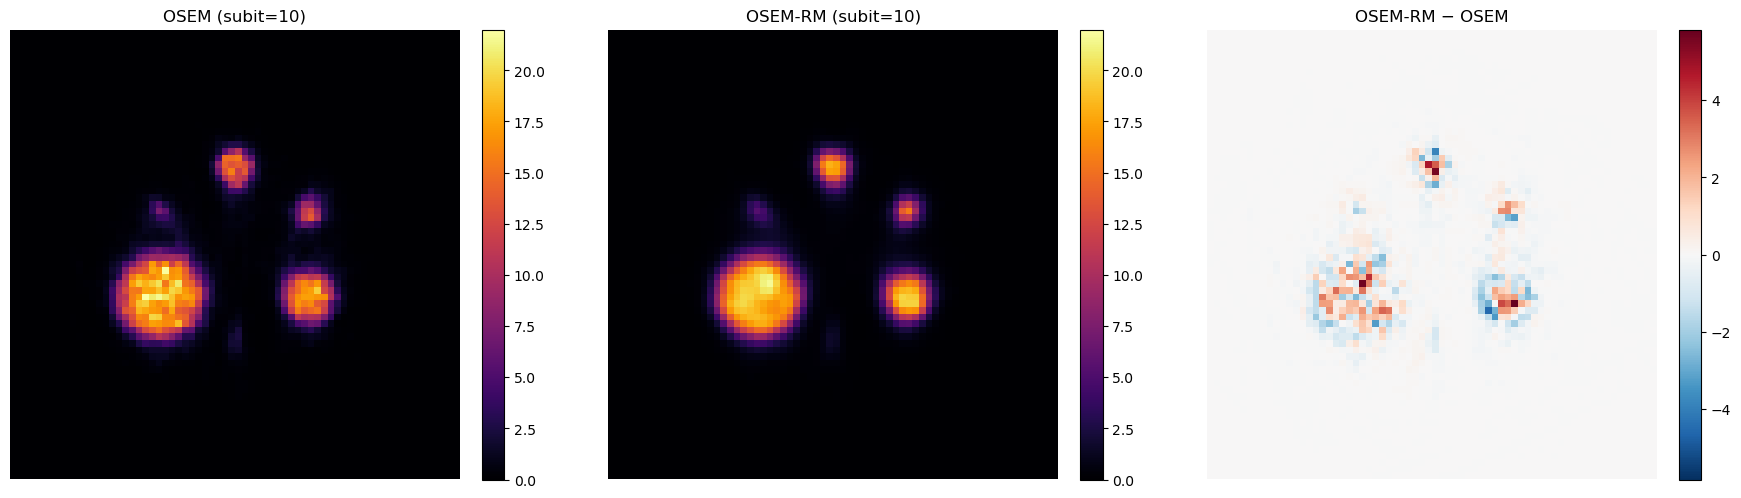

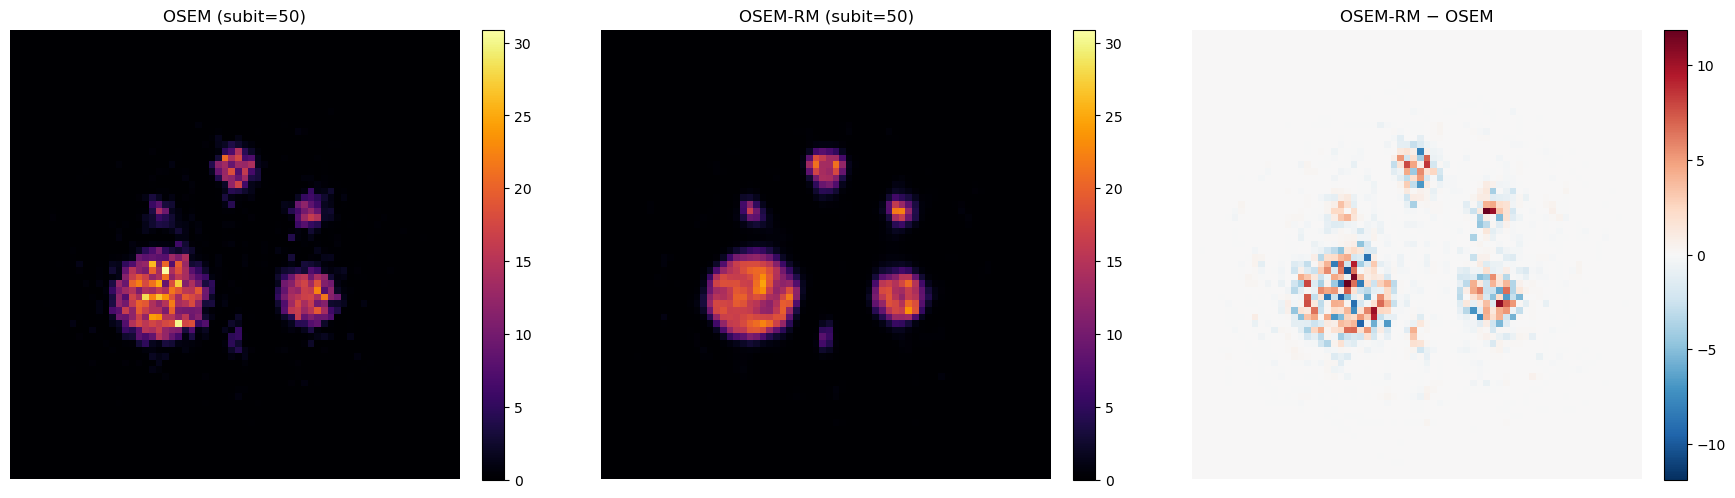

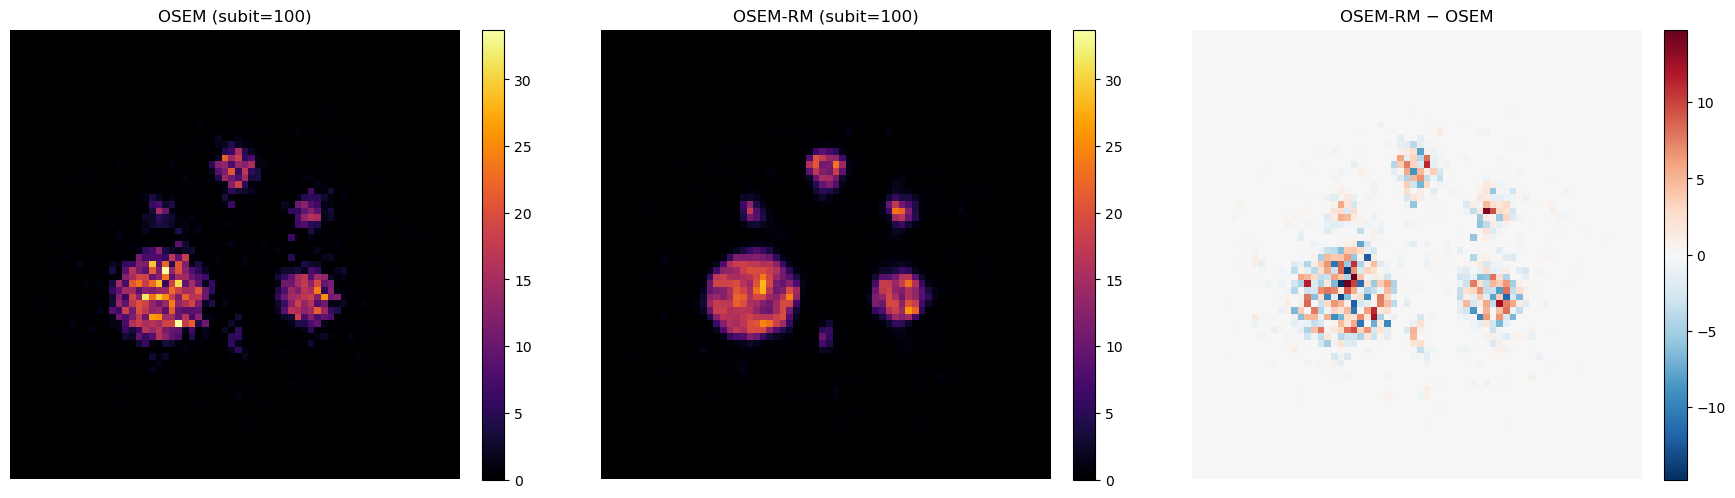

In [8]:
osem_recon_dir = sim_dir / "recons" / "osem"
osem_rm_recon_dir = sim_dir / "recons" / "osem_rm"

idx = (56, slice(30, 98), slice(30, 98))
display_subiterations = [10, 50, 100]

for it in display_subiterations:
    osem_arr = spect.ImageData(
        str(osem_recon_dir / f"lu177_sim_osem_{it}.hv")
    ).as_array()

    osem_rm_arr = spect.ImageData(
        str(osem_rm_recon_dir / f"lu177_sim_osem_rm_{it}.hv")
    ).as_array()

    difference = osem_rm_arr - osem_arr

    vmax = max(
        np.max(osem_arr[idx]),
        np.max(osem_rm_arr[idx]),
    )
    difference_max = np.max(np.abs(difference[idx]))

    utils.display_arr(
        arr_3d=[osem_arr, osem_rm_arr, difference],
        idx=idx,
        titles=[
            f"OSEM (subit={it})",
            f"OSEM-RM (subit={it})",
            "OSEM-RM − OSEM",
        ],
        vmax=[vmax, vmax, difference_max],
        vmin=[0, 0, -difference_max],
        cmap=["inferno", "inferno", "RdBu_r"],
    )


## From Reconstruction to Quantitative Evaluation

Simulation provides an important advantage for reconstruction evaluation: the **underlying digital activity distribution is known**.

The workflow now contains all the elements required for quantitative validation:

**known activity distribution → SIMIND projections → scatter correction → reconstruction → comparison with the known source**

In the next notebook, the saved reconstructions are compared with the source distribution to investigate **convergence and recovery**, and to compare reconstruction behaviour for **Tc-99m and Lu-177**.
